In [2]:
from google.colab import files

uploaded = files.upload()

Saving training_vs_ideal_mapping.zip to training_vs_ideal_mapping.zip


In [3]:
import os
os.listdir('/content')

['.config', 'training_vs_ideal_mapping.zip', 'sample_data']

In [4]:
import zipfile

zip_path = "/content/training_vs_ideal_mapping.zip"
extract_path = "/content/dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [5]:
import os

os.listdir('/content/dataset')

['waterpollution']

In [6]:
import os

dataset_path = "/content/dataset/waterpollution"

print(os.listdir(dataset_path))

['image_207.jpg', 'image_196.jpg', 'image_257.jpg', 'image_189.jpg', 'image_193.jpg', 'image_011.jpg', 'image_098.jpg', 'image_066.jpg', 'image_263.jpg', 'image_152.jpg', 'image_223.jpg', 'image_099.jpg', 'image_077.jpg', 'image_088.jpg', 'image_240.jpg', 'image_200.jpg', 'image_148.JPG', 'image_030.jpg', 'image_001.jpg', 'image_064.jpg', 'image_259.jpg', 'image_082.jpg', 'image_166.jpg', 'image_038.jpg', 'image_031.jpg', 'image_081.jpg', 'image_181.jpg', 'image_052.jpg', 'image_127.jpg', 'image_029.jpg', 'image_268.jpg', 'image_104.jpg', 'image_241.png', 'image_172.jpg', 'image_272.jpg', 'image_213.jpg', 'image_002.jpeg', 'image_015.jpg', 'image_224.jpg', 'image_087.jpg', 'image_252.jpg', 'image_094.jpg', 'image_198.jpg', 'image_188.jpg', 'image_155.png', 'image_274.jpg', 'image_138.jpg', 'image_271.jpg', 'image_141.jpg', 'image_130.jpg', 'image_243.jpg', 'image_063.jpg', 'image_027.jpg', 'image_178.jpg', 'image_033.jpg', 'image_170.jpg', 'image_083.jpg', 'image_057.jpg', 'image_006.p

In [7]:
import os
import shutil
import random

source_folder = "/content/dataset/waterpollution"

base_dir = "/content/water_dataset"
clean_dir = os.path.join(base_dir, "clean")
polluted_dir = os.path.join(base_dir, "polluted")

os.makedirs(clean_dir, exist_ok=True)
os.makedirs(polluted_dir, exist_ok=True)

images = os.listdir(source_folder)
random.shuffle(images)

split_index = len(images) // 2

clean_images = images[:split_index]
polluted_images = images[split_index:]

for img in clean_images:
    shutil.copy(os.path.join(source_folder, img), os.path.join(clean_dir, img))

for img in polluted_images:
    shutil.copy(os.path.join(source_folder, img), os.path.join(polluted_dir, img))

print("Dataset organized successfully!")

Dataset organized successfully!


In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/water_dataset"

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 235 images belonging to 2 classes.
Found 58 images belonging to 2 classes.


In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,169,089 (42.61 MB)

 Trainable params: 11,169,089 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
from PIL import Image
import os

dataset_path = "/content/water_dataset"

for class_name in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):
        image_path = os.path.join(class_path, image_name)

        try:
            img = Image.open(image_path)
            img.verify()

        except:
            print("Removing corrupted image:", image_path)
            os.remove(image_path)

print("Corrupted images removed successfully!")

Corrupted images removed successfully!


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

dataset_path = "/content/water_dataset"

img_size = (224, 224)
batch_size = 32

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='binary',
    subset='validation'
)

Found 234 images belonging to 2 classes.
Found 58 images belonging to 2 classes.


In [14]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=10
)

Epoch 1/10
2/8 ━━━━━━━━━━━━━━━━━━━━ 25s 4s/step - accuracy: 0.4375 - loss: 1.3809

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


8/8 ━━━━━━━━━━━━━━━━━━━━ 40s 5s/step - accuracy: 0.4701 - loss: 1.2981 - val_accuracy: 0.5000 - val_loss: 0.6930
Epoch 2/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 34s 4s/step - accuracy: 0.5171 - loss: 0.7045 - val_accuracy: 0.5000 - val_loss: 0.7004
Epoch 3/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.5171 - loss: 0.6906 - val_accuracy: 0.5345 - val_loss: 0.6922
Epoch 4/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.5513 - loss: 0.6907 - val_accuracy: 0.5862 - val_loss: 0.6867
Epoch 5/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.5641 - loss: 0.6977 - val_accuracy: 0.5000 - val_loss: 0.6942
Epoch 6/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.6239 - loss: 0.6584 - val_accuracy: 0.5000 - val_loss: 0.7132
Epoch 7/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 35s 4s/step - accuracy: 0.6239 - loss: 0.6377 - val_accuracy: 0.5000 - val_loss: 0.7075
Epoch 8/10
8/8 ━━━━━━━━━━━━━━━━━━━━ 33s 4s/step - accuracy: 0.6880 - loss: 0.6069 - val_accuracy: 0.5862 - val_loss: 0.7092
Epoch 9/10
8/8 ━━━━

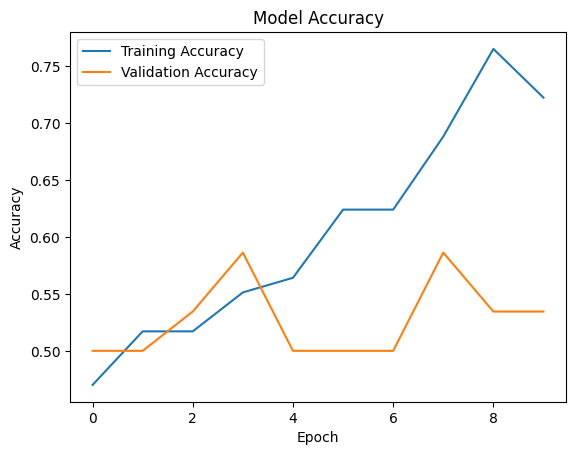

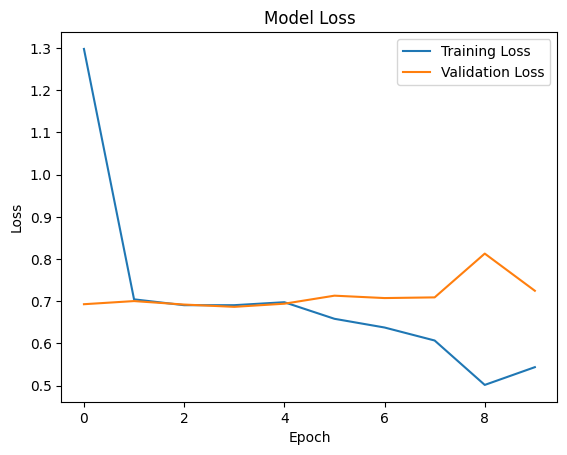

In [15]:
import matplotlib.pyplot as plt

# Accuracy Graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss Graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [16]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

2/2 ━━━━━━━━━━━━━━━━━━━━ 4s 991ms/step - accuracy: 0.5345 - loss: 0.7248
Validation Accuracy: 0.5344827771186829
Validation Loss: 0.7248255014419556


2/2 ━━━━━━━━━━━━━━━━━━━━ 8s 2s/step
Confusion Matrix:
[[13 16]
 [ 5 24]]

Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.45      0.55        29
           1       0.60      0.83      0.70        29

    accuracy                           0.64        58
   macro avg       0.66      0.64      0.62        58
weighted avg       0.66      0.64      0.62        58



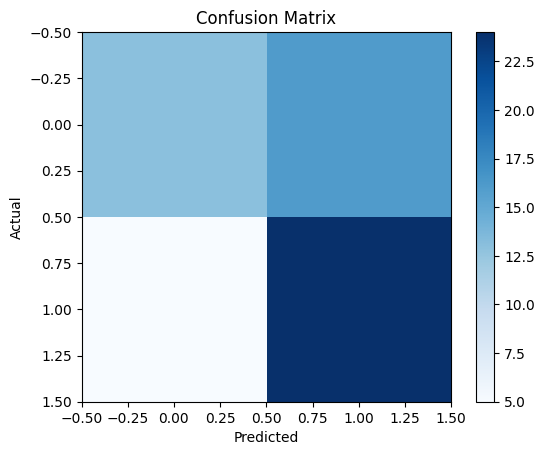

In [17]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Predictions
predictions = model.predict(val_data)
predicted_classes = (predictions > 0.5).astype(int)

true_classes = val_data.classes

# Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

print("Confusion Matrix:")
print(cm)

# Classification Report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes))

# Plot confusion matrix
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')
plt.colorbar()

plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()